In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import os

base_path = "../Check_data"
all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)


In [11]:
# trim the first 3 seconds and the last 3
def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

# ID als separate Spalte sichern bevor groupby sie verschluckt
final_df["ID_backup"] = final_df["ID"]

df = (
    final_df
    .groupby("ID_backup", group_keys=False)
    .apply(trim_measurement)
    .reset_index(drop=True)
)


In [12]:
df.head()

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
0,2026-04-02 05:23:56.825004300,3.103004,-0.050991,0.054473,-0.248501,Accelerometer,Lift,0
1,2026-04-02 05:23:56.833337000,3.111337,-0.054046,-0.007708,-0.233085,Accelerometer,Lift,0
2,2026-04-02 05:23:56.841670100,3.119670,-0.050421,0.004938,-0.159093,Accelerometer,Lift,0
3,2026-04-02 05:23:56.850003200,3.128003,-0.063947,-0.091688,-0.268553,Accelerometer,Lift,0
4,2026-04-02 05:23:56.858336300,3.136336,-0.015999,-0.099129,-0.271838,Accelerometer,Lift,0


In [13]:
# Check if every ID has a Tag
df.groupby(["ID"]).Tag.apply(lambda x: x.isna().any())

ID
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
Name: Tag, dtype: bool

In [14]:
df.groupby("ID")["Tag"].unique()

ID
0     [Lift]
1     [Lift]
2     [Lift]
3     [Lift]
4     [Lift]
5     [Lift]
6     [Lift]
7     [Lift]
8     [Lift]
9     [Lift]
10    [Lift]
11    [Lift]
Name: Tag, dtype: object

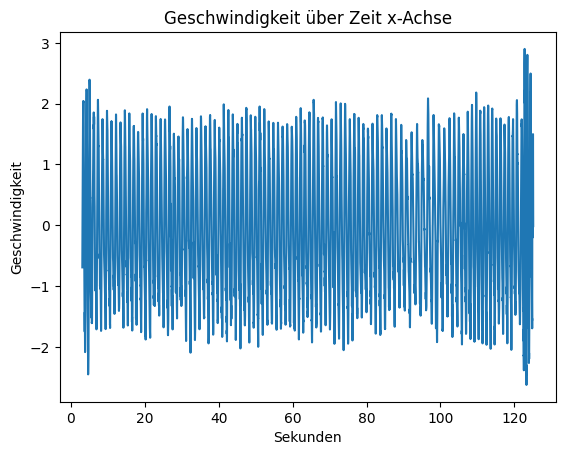

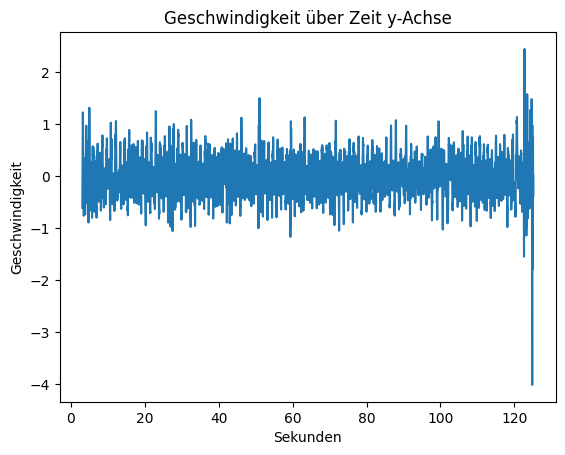

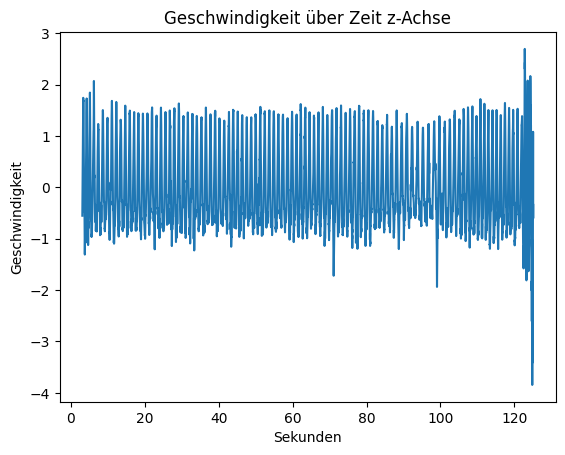

In [7]:
speed = df[(df["Sensor"] == "Gyroscope") & (df['ID'] == 1)]

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.plot(speed['seconds_elapsed'], speed["x"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit x-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["y"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit y-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["z"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit z-Achse")
plt.show()

# Falls man mehrere Daten anschauen möchte

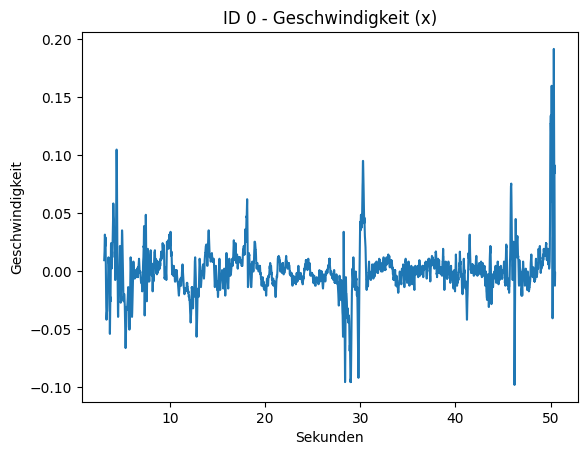

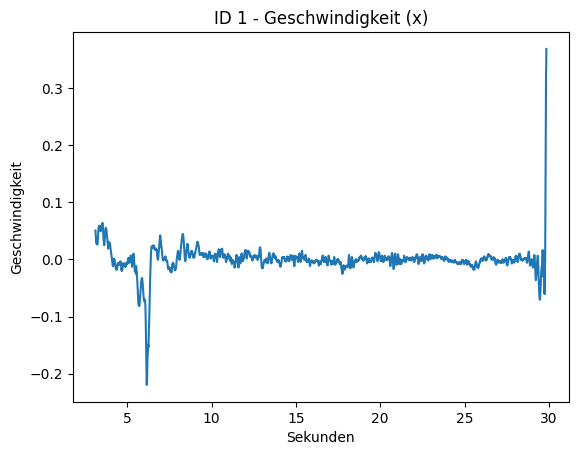

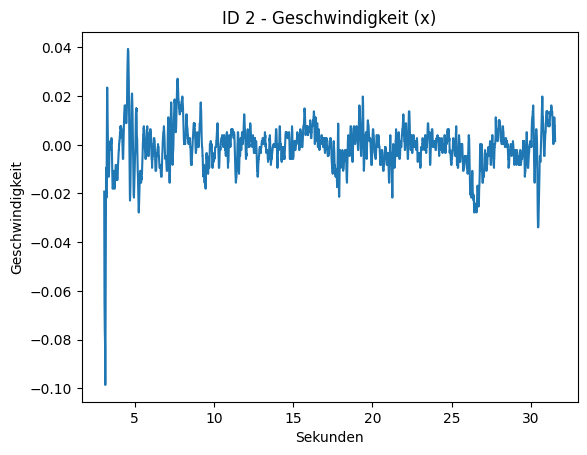

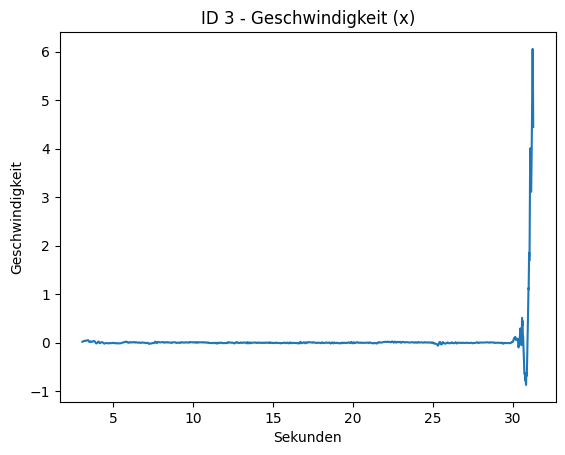

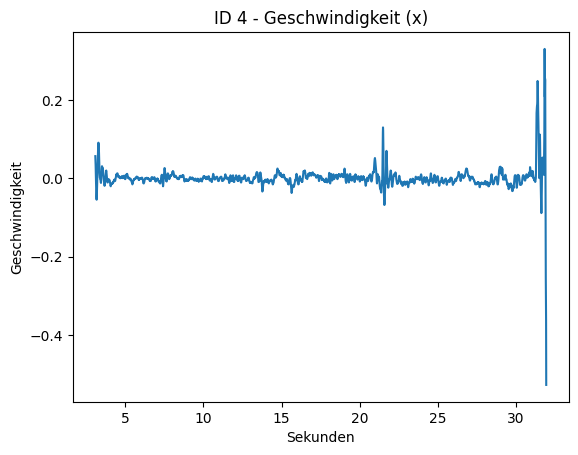

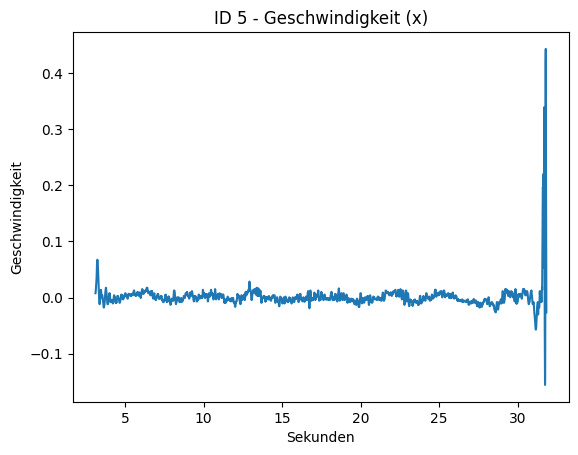

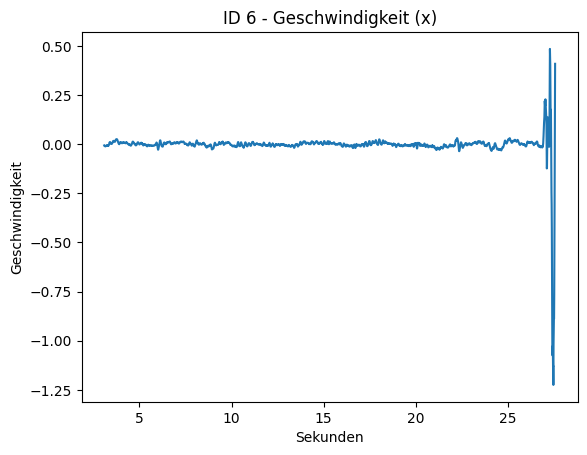

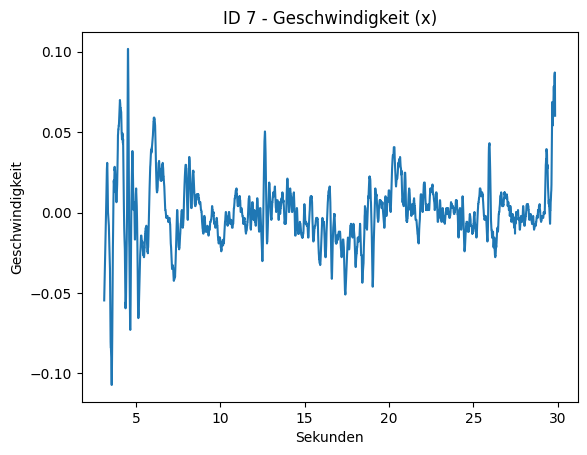

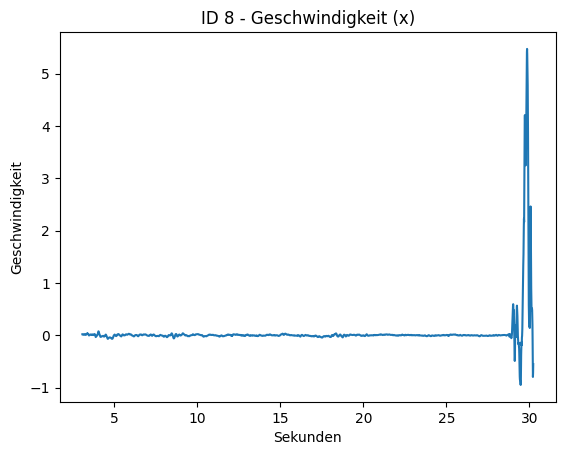

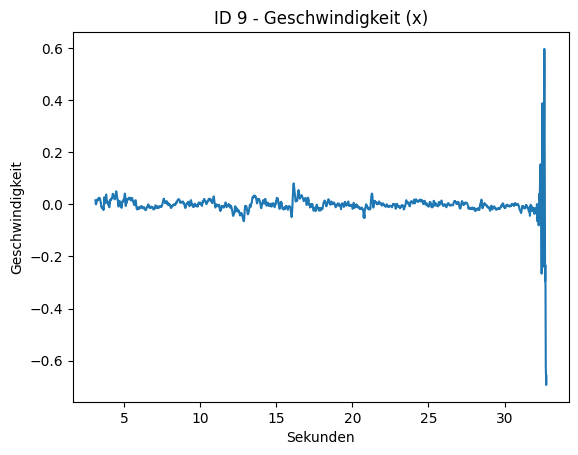

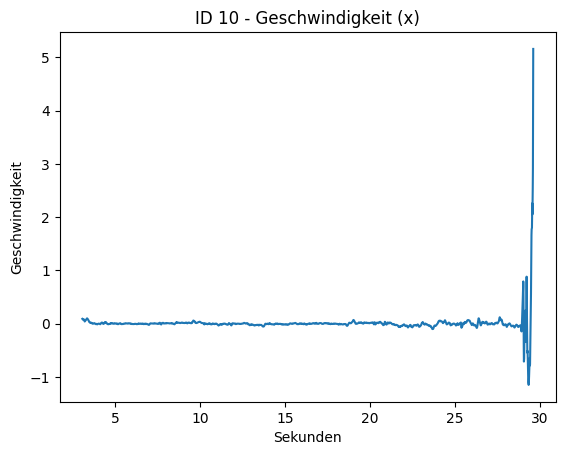

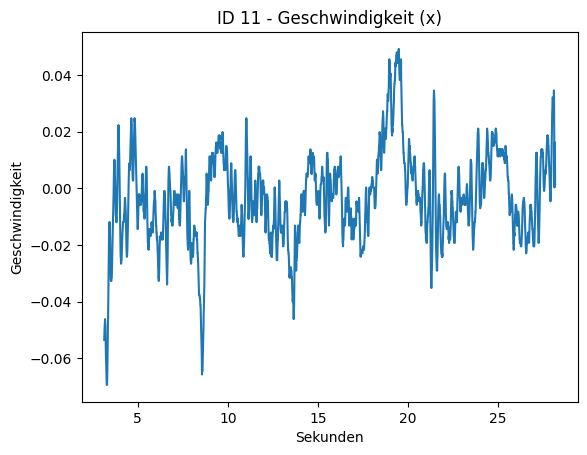

In [15]:
end_ID = 11

speed = df[(df["Sensor"] == "Gyroscope") & (df["ID"].between(0, end_ID))]

for i in range(end_ID + 1):
    subset = speed[speed["ID"] == i]
    
    # X-Achse
    plt.figure()
    plt.plot(subset["seconds_elapsed"], subset["x"])
    plt.xlabel("Sekunden")
    plt.ylabel("Geschwindigkeit")
    plt.title(f"ID {i} - Geschwindigkeit (x)")
    plt.show()

    # Y-Achse
    #plt.figure()
    #plt.plot(subset["seconds_elapsed"], subset["y"])
    #plt.xlabel("Sekunden")
    #plt.ylabel("Geschwindigkeit")
    #plt.title(f"ID {i} - Geschwindigkeit (y)")
    #plt.show()

    # Z-Achse
    #plt.figure()
    #plt.plot(subset["seconds_elapsed"], subset["z"])
    #plt.xlabel("Sekunden")
    #plt.ylabel("Geschwindigkeit")
    #plt.title(f"ID {i} - Geschwindigkeit (z)")
    #plt.show()